In [1]:
import sqlite3
import pandas as pd
import seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
pd.options.display.max_rows = 20
pd.options.display.max_columns = 90

# Loading sql

In [2]:
import os, shutil

source = "gas_monitoring.db.example"
target = "gas_monitoring.db"

if not os.path.exists(source):
    raise FileNotFoundError(
        f"{source} not found — did you clone the full repo?"
    )
if os.path.exists(target):
    os.remove(target)
shutil.copy2(source, target)
print(f"Copied {source} → {target}")

Copied gas_monitoring.db.example → gas_monitoring.db


In [3]:
con = sqlite3.connect('gas_monitoring.db')

In [4]:
cursor = con.cursor()

        # Query the sqlite_master table to get table names
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")

        # Fetch all results
table_names = [row[0] for row in cursor.fetchall()]


In [5]:
query = "SELECT * FROM gas_monitoring"  # Replace 'your_table_name' with the actual table name
df = pd.read_sql_query(query, con)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   8072 non-null   float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     8590 non-null   float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               9166 non-null   float64
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

# Initial Analysis

### Temperature

In [7]:
display(df['Temperature'].describe())

,Temperature
count,10000.000000
mean,42.243124
std,73.974956
min,6.903485
25%,18.937500
50%,20.510000
75%,23.172500
max,307.070000


In [8]:
anomalies_temp = df[df['Temperature'] > 100]
print(f"Found {len(anomalies_temp)} rows with Temperature > 100")
display(anomalies_temp.head(10))

Found 795 rows with Temperature > 100


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity
8,afternoon,292.59,47.92,74.100322,624.577270,564.745091,798.290403,753.467986,674.278245,0.0,7241,maintenance_mode,very_bright,Low Activity
24,afternoon,292.65,51.95,84.581085,617.316915,534.905951,767.204960,717.770588,617.513808,1.0,7241,eco_mode,very_bright,Moderate Activity
27,morning,292.17,50.12,79.585071,614.239997,517.352383,762.802020,549.291994,667.030718,NaN,3856,ventilation_only,very_bright,Moderate Activity
28,afternoon,295.04,51.34,115.203695,571.393272,499.873896,NaN,802.571265,575.355790,2.0,4761,ventilation_only,very_bright,Low Activity
42,afternoon,293.81,49.07,74.411945,620.217312,399.022768,753.892766,705.797216,624.878193,1.0,7241,eco_mode,bright,High Activity
43,afternoon,295.10,47.17,78.710400,565.693739,520.455398,761.671720,713.629882,661.187642,0.0,4703,heating_active,moderate,Moderate Activity
90,evening,296.98,49.94,107.094146,600.834256,433.617367,742.350422,677.251205,613.420451,1.0,7241,off,moderate,High Activity
106,evening,297.30,48.34,110.552913,605.145553,437.118871,727.891895,671.712921,602.391350,2.0,7241,eco_mode,None,Moderate Activity
108,evening,297.91,48.51,120.220801,599.237428,407.045481,719.665665,655.334968,570.877422,2.0,7241,ventilation_only,very_dim,Low Activity


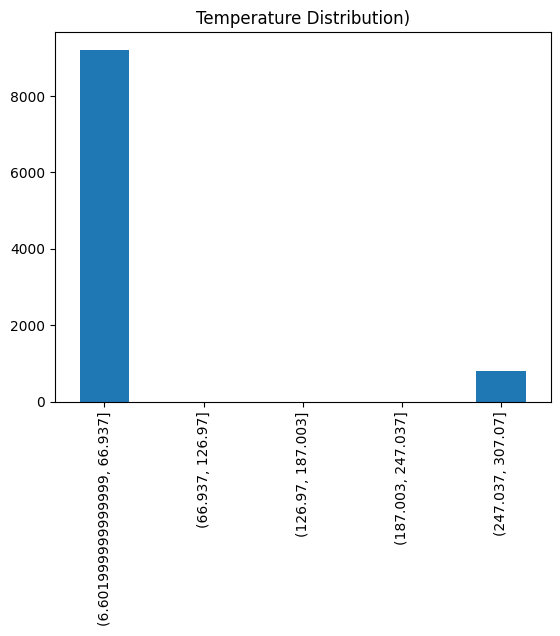

In [9]:
df['Temperature'].value_counts(bins=5).sort_index().plot(kind='bar')
plt.title('Temperature Distribution)')
plt.show()

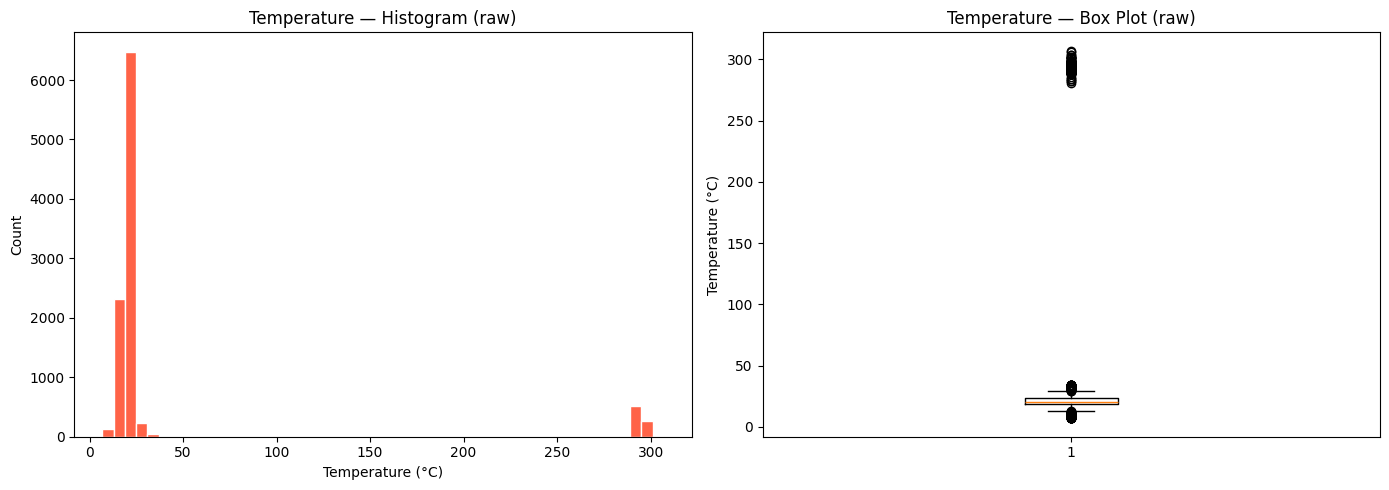

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax1.hist(df['Temperature'], bins=50, color='tomato', edgecolor='white')
ax1.set_title('Temperature — Histogram (raw)')
ax1.set_xlabel('Temperature (°C)')
ax1.set_ylabel('Count')

# Box plot
ax2.boxplot(df['Temperature'].dropna())
ax2.set_title('Temperature — Box Plot (raw)')
ax2.set_ylabel('Temperature (°C)')

plt.tight_layout()
plt.show()

In [11]:
anomalies_temp = df[df['Temperature'] > 60]
print(f'Rows with Temperature > 60°C: {len(anomalies_temp)}')
display(anomalies_temp[['Temperature']].head(10))

Rows with Temperature > 60°C: 795


,Temperature
1,292.81
8,292.59
24,292.65
27,292.17
28,295.04
42,293.81
43,295.10
90,296.98
106,297.30
108,297.91


> **Insights:**
> - The histogram reveals a bimodal-looking distribution with a long right tail — driven by unrealistic high values (up to 307°C).
> - Box plot shows extreme outliers well above the expected indoor range.
> - **Action:** Replace Temperature > 60°C with `NaN`, then impute with the column median.

### Humidity

In [12]:
display(df['Humidity'].describe())
display(df['Humidity'].isna().sum() / df.shape[0])
neg_humidity = df[df['Humidity'] < 0]
print(f"Found {len(neg_humidity)} rows with negative Humidity")
display(neg_humidity.head(10))

,Humidity
count,8072.000000
mean,51.643609
std,21.333894
min,-49.870000
25%,47.660000
50%,51.390000
75%,53.840000
max,198.900000


np.float64(0.1928)

Found 207 rows with negative Humidity


,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level
9,night,19.81,-48.34,8.964022,595.833260,464.828130,737.958044,687.714744,622.836602,NaN,2105,ventilation_only,None,Low Activity
120,night,18.57,-14.79,121.184923,579.703970,468.239926,NaN,678.065464,620.466497,1.0,2679,cooling_active,very_bright,Moderate Activity
146,night,19.69,-18.73,120.017584,549.422635,459.086470,692.412305,645.741758,571.745341,2.0,7058,off,bright,Low Activity
214,night,19.67,-4.01,235.217715,600.656020,473.844566,729.094245,686.763442,606.800807,2.0,7241,eco_mode,very_bright,Low Activity
282,morning,20.09,-35.48,94.681893,608.264815,511.404061,759.890965,714.800339,647.422277,1.0,3856,maintenance_mode,very_bright,Moderate Activity
314,afternoon,19.92,-3.44,66.259508,619.804128,550.239471,776.672154,744.301505,672.195693,0.0,3856,HEATING_ACTIVE,moderate,Moderate Activity
335,morning,17.22,-49.87,207.966266,581.456914,498.282281,740.936450,701.413862,639.873640,1.0,2679,off,bright,Moderate Activity
489,afternoon,18.59,-44.30,76.004016,576.693498,541.079818,752.677561,719.166414,661.696568,NaN,2847,cooling_active,dim,Low Activity
534,morning,19.08,-43.56,102.745796,602.036350,489.720394,733.325098,675.358312,606.899771,1.0,3856,MAINTENANCE_MODE,moderate,Moderate Activity
621,afternoon,297.83,-15.50,97.071508,606.209951,463.731986,742.921479,696.513108,644.773915,1.0,9127,MAINTENANCE_MODE,moderate,Moderate Activity


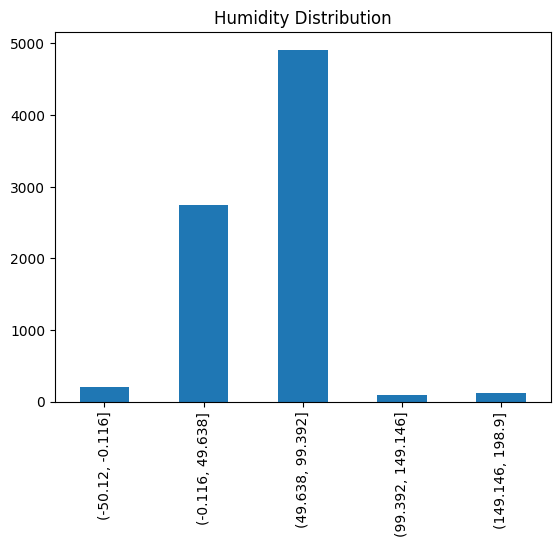

In [13]:
df['Humidity'].value_counts(bins=5).sort_index().plot(kind='bar')
plt.title('Humidity Distribution')
plt.show()

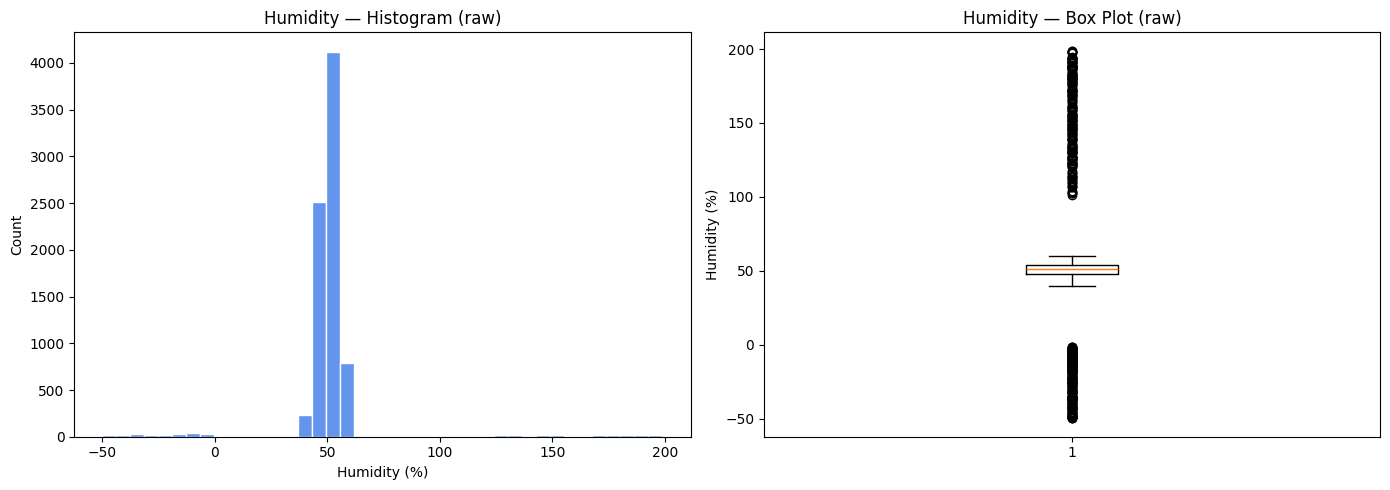

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(df['Humidity'].dropna(), bins=40, color='cornflowerblue', edgecolor='white')
ax1.set_title('Humidity — Histogram (raw)')
ax1.set_xlabel('Humidity (%)')
ax1.set_ylabel('Count')

ax2.boxplot(df['Humidity'].dropna())
ax2.set_title('Humidity — Box Plot (raw)')
ax2.set_ylabel('Humidity (%)')

plt.tight_layout()
plt.show()

In [15]:
neg_humidity = df[df['Humidity'] < 0]
over100_humidity = df[df['Humidity'] > 100]
print(f'Rows with Humidity < 0   : {len(neg_humidity)}')
print(f'Rows with Humidity > 100 : {len(over100_humidity)}')

Rows with Humidity < 0   : 207
Rows with Humidity > 100 : 207


Insights:

19.3% missing values — above the 5% drop threshold, so imputation is the right strategy.
Negative humidity and values > 100% are physically impossible — clear data entry errors.
Action: Replace invalid values (< 0 or > 100) with NaN, then impute with median.

### CO2_InfraredSensor

In [16]:
display(df[['CO2_InfraredSensor']].describe())

,CO2_InfraredSensor
count,10000.000000
mean,109.864352
std,33.793851
min,-17.472184
25%,96.660377
50%,112.807103
75%,124.540226
max,237.873938


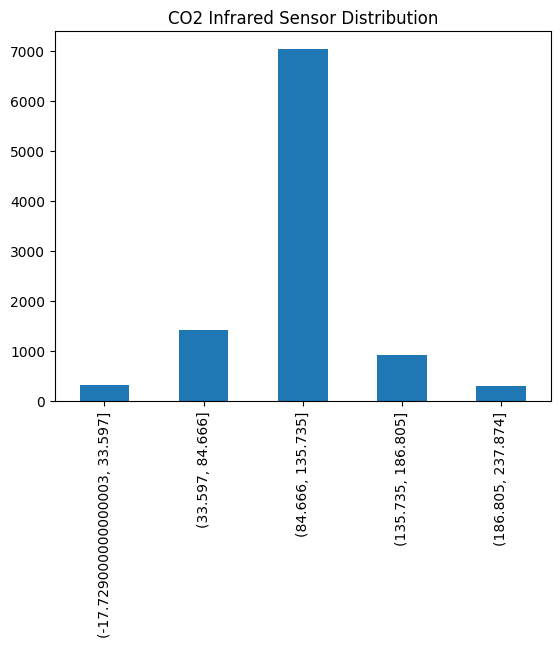

In [17]:
df['CO2_InfraredSensor'].value_counts(bins=5).sort_index().plot(kind='bar')
plt.title('CO2 Infrared Sensor Distribution')
plt.show()

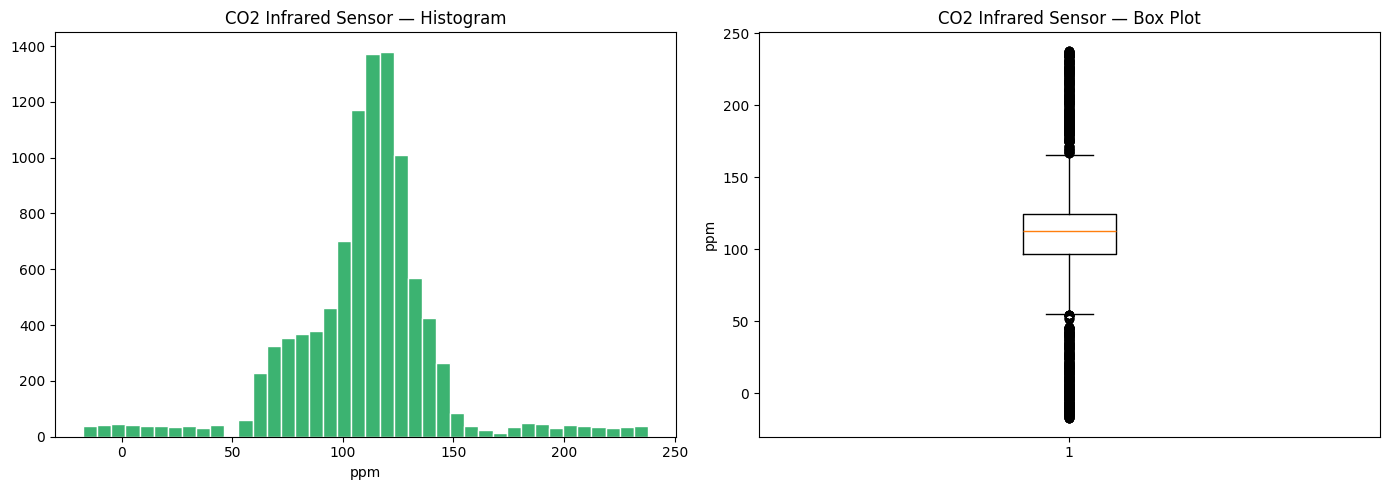

In [18]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(df['CO2_InfraredSensor'], bins=40, color='mediumseagreen', edgecolor='white')
ax1.set_title('CO2 Infrared Sensor — Histogram')
ax1.set_xlabel('ppm')
ax2.boxplot(df['CO2_InfraredSensor'].dropna())
ax2.set_title('CO2 Infrared Sensor — Box Plot')
ax2.set_ylabel('ppm')
plt.tight_layout()
plt.show()

In [19]:
# IQR outlier detection
Q1 = df['CO2_InfraredSensor'].quantile(0.25)
Q3 = df['CO2_InfraredSensor'].quantile(0.75)
IQR = Q3 - Q1
lower_co2ir = Q1 - 1.5 * IQR
upper_co2ir = Q3 + 1.5 * IQR
outliers_co2ir = df[(df['CO2_InfraredSensor'] < lower_co2ir) | (df['CO2_InfraredSensor'] > upper_co2ir)]
print(f'IQR bounds: [{lower_co2ir:.1f}, {upper_co2ir:.1f}]')
print(f'Outliers: {len(outliers_co2ir)} ({len(outliers_co2ir)/len(df)*100:.1f}%)')

IQR bounds: [54.8, 166.4]
Outliers: 805 (8.1%)


Insights: No missing values. ~8% IQR outliers exist but CO2 readings can legitimately spike during high activity — these will be retained and considered during modelling.

### CO2_ElectroChemicalSensor

In [20]:
display(df['CO2_ElectroChemicalSensor'].describe())

,CO2_ElectroChemicalSensor
count,10000.000000
mean,578.634082
std,22.573537
min,408.599386
25%,559.353100
50%,579.361082
75%,595.569759
max,637.895790


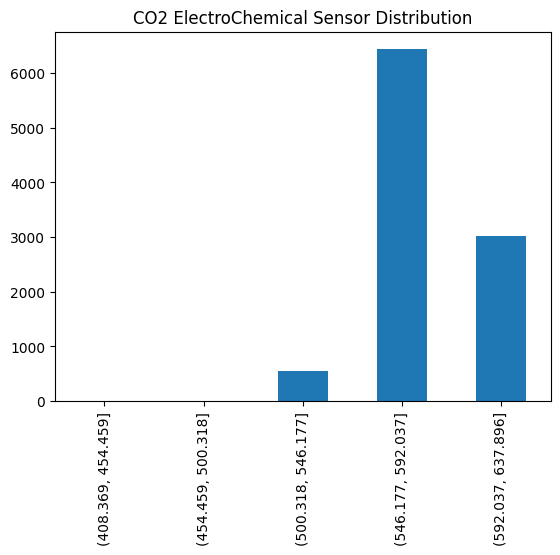

In [21]:
df['CO2_ElectroChemicalSensor'].value_counts(bins=5).sort_index().plot(kind='bar')
plt.title('CO2 ElectroChemical Sensor Distribution')
plt.show()

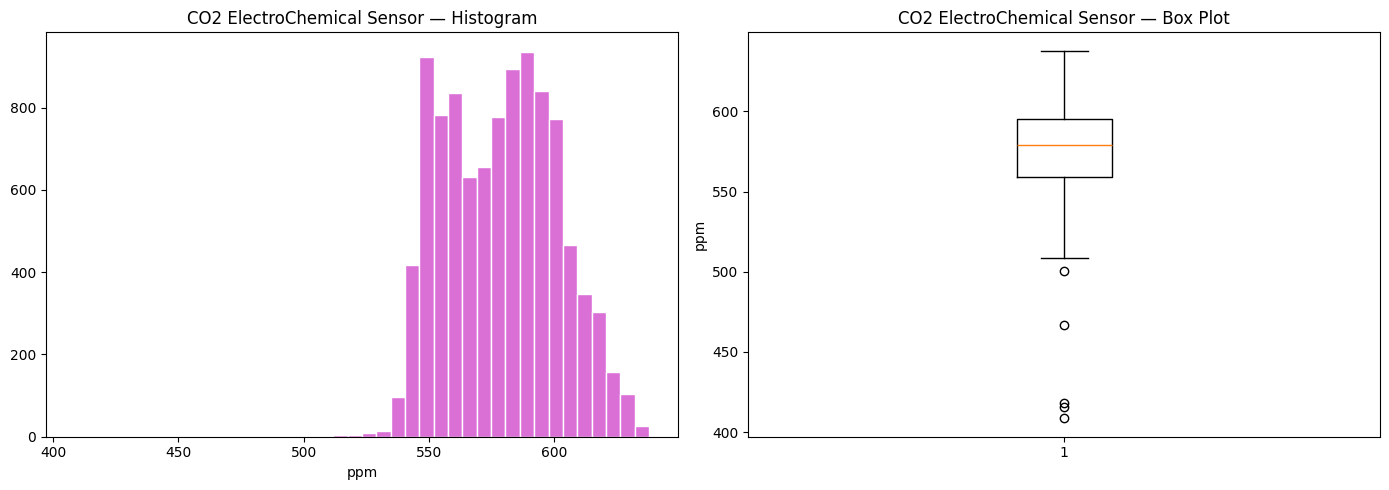

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.hist(df['CO2_ElectroChemicalSensor'], bins=40, color='orchid', edgecolor='white')
ax1.set_title('CO2 ElectroChemical Sensor — Histogram')
ax1.set_xlabel('ppm')
ax2.boxplot(df['CO2_ElectroChemicalSensor'].dropna())
ax2.set_title('CO2 ElectroChemical Sensor — Box Plot')
ax2.set_ylabel('ppm')
plt.tight_layout()
plt.show()

Insights: Very clean column — no missing values, only 5 IQR outliers (0.1%). Distribution is narrow and well-behaved. No cleaning action required.

### CO_GasSensor

In [23]:
display(df['CO_GasSensor'].value_counts())
display(df['CO_GasSensor'].isna().sum() / df.shape[0])

,count
CO_GasSensor,
1.0,4722
2.0,2748
0.0,1191
3.0,430
4.0,75


np.float64(0.0834)

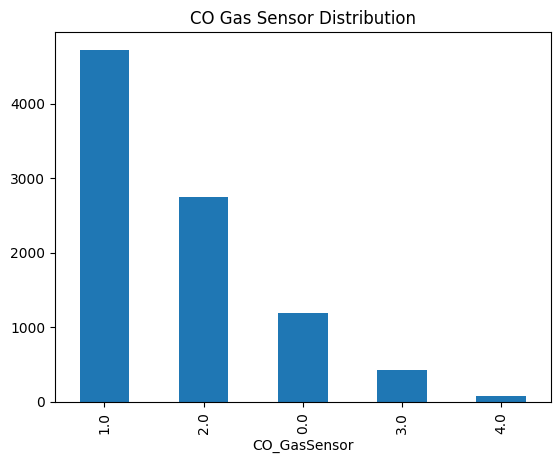

In [24]:
df['CO_GasSensor'].value_counts().plot(kind='bar')
plt.title('CO Gas Sensor Distribution')
plt.show()

### Metal Oxide Sensors (Units 1–4)

In [25]:
mo_cols = [
    'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit2',
    'MetalOxideSensor_Unit3',
    'MetalOxideSensor_Unit4'
]
display(df[mo_cols].describe())

,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4
count,10000.000000,8590.000000,10000.000000,10000.000000
mean,470.932316,728.354408,680.488646,612.247715
std,51.459025,29.140123,55.953530,43.174354
min,286.825662,611.168916,456.673900,412.791904
25%,440.035413,709.660122,658.519775,585.511731
50%,469.146955,726.748925,679.908353,609.526245
75%,494.770045,744.879789,703.522845,636.012105
max,632.891693,807.732943,906.213097,736.112361


In [26]:
display(df[mo_cols].isna().sum())

,0
MetalOxideSensor_Unit1,0
MetalOxideSensor_Unit2,1410
MetalOxideSensor_Unit3,0
MetalOxideSensor_Unit4,0


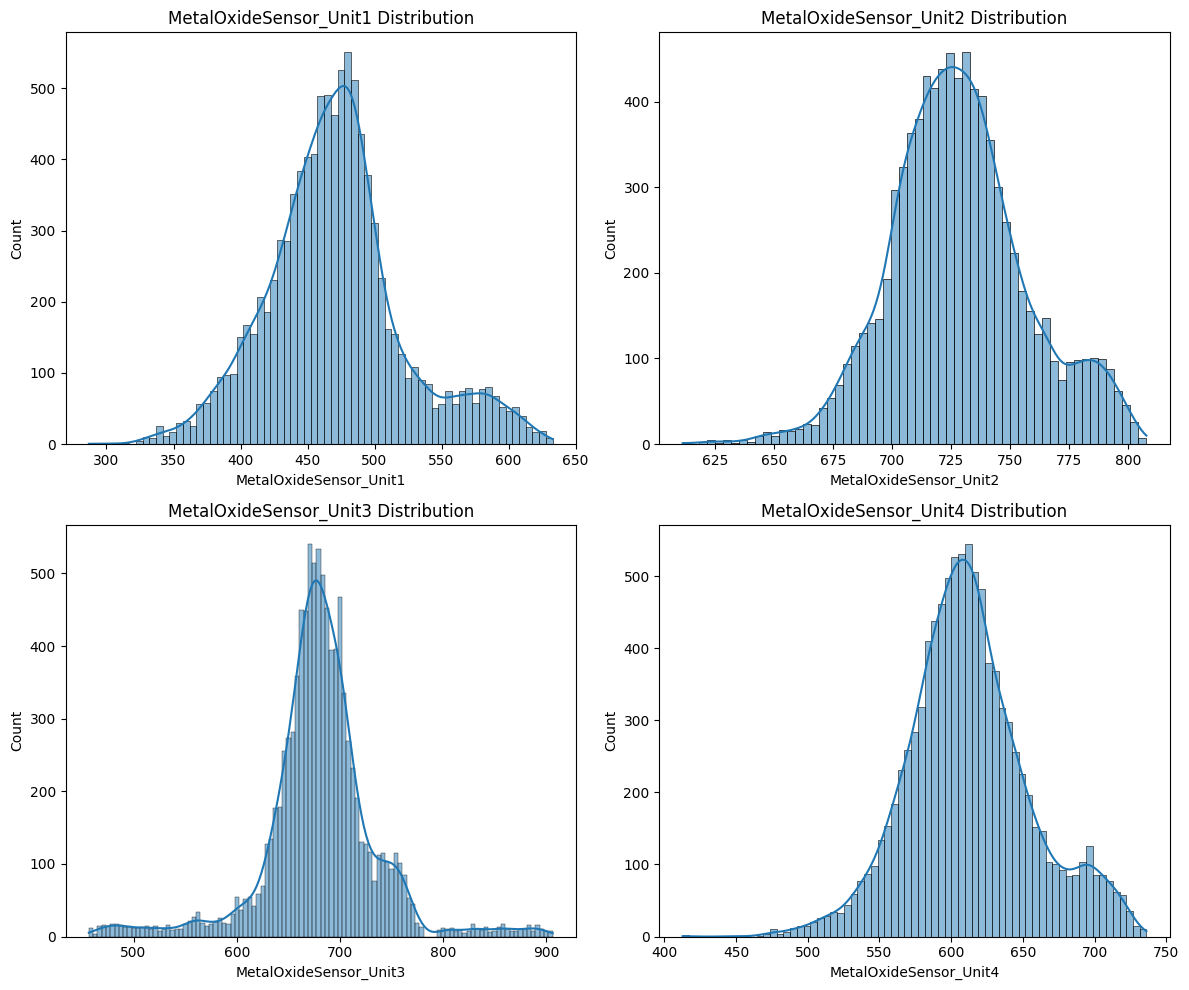

In [27]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, col in zip(axes.ravel(), mo_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(f'{col} Distribution')
plt.tight_layout()
plt.show()

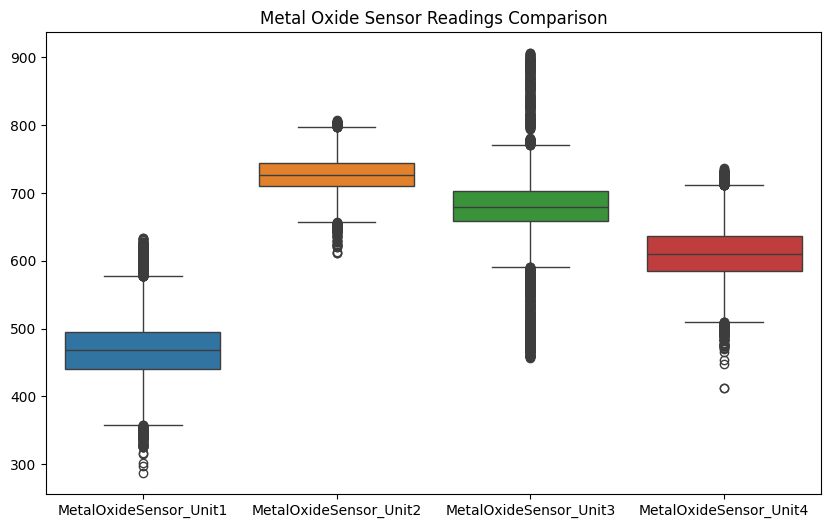

In [28]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df[mo_cols])
plt.title('Metal Oxide Sensor Readings Comparison')
plt.show()

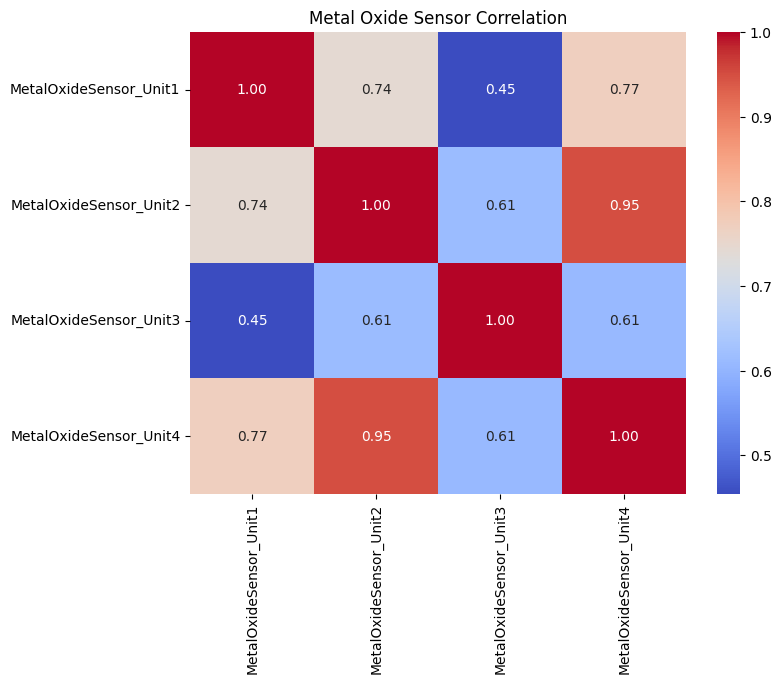

In [29]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[mo_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Metal Oxide Sensor Correlation')
plt.show()

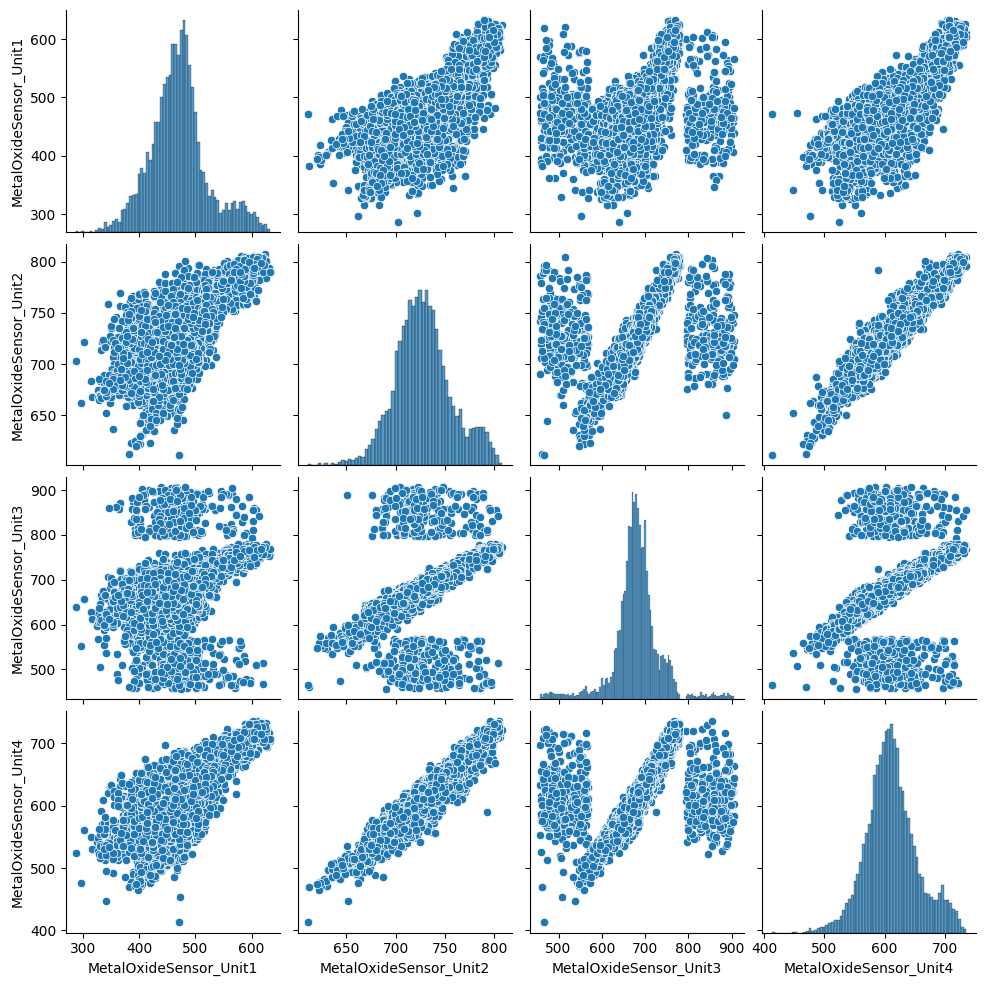

In [30]:
sns.pairplot(df[mo_cols])
plt.show()

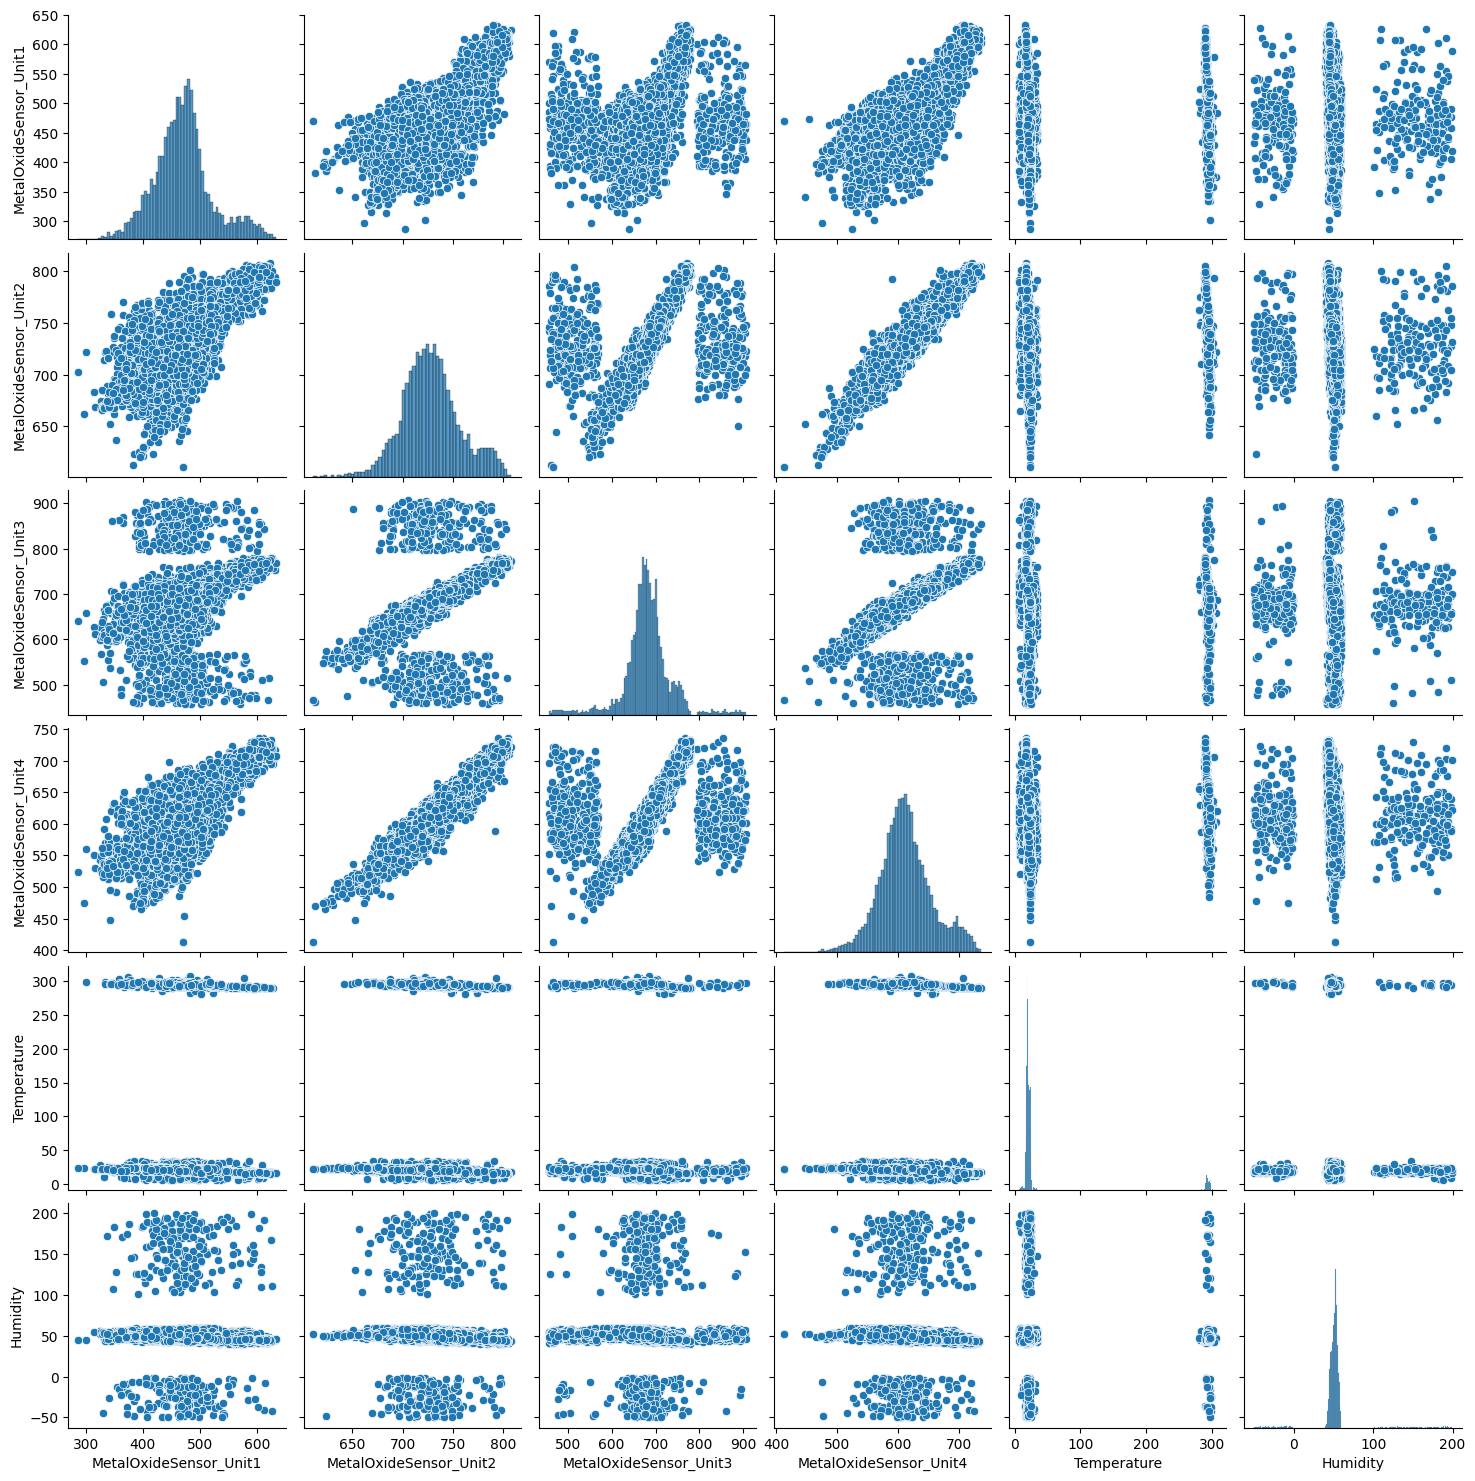

In [31]:
sns.pairplot(df[mo_cols + ['Temperature', 'Humidity']])
plt.show()

<Figure size 1200x600 with 0 Axes>

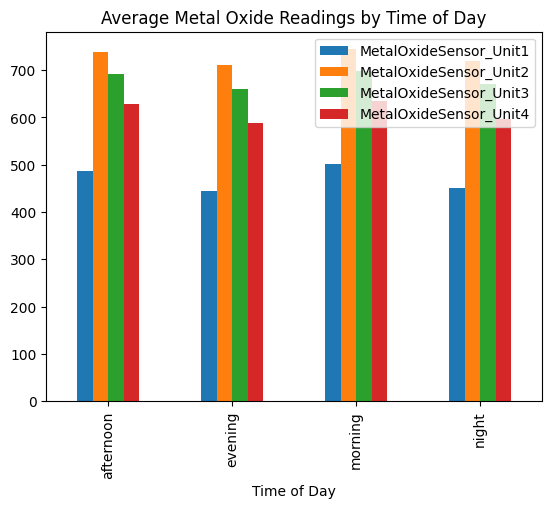

In [32]:
plt.figure(figsize=(12, 6))
df.groupby('Time of Day')[mo_cols].mean().plot(kind='bar')
plt.title('Average Metal Oxide Readings by Time of Day')
plt.legend(loc='best')
plt.show()

<Figure size 1200x600 with 0 Axes>

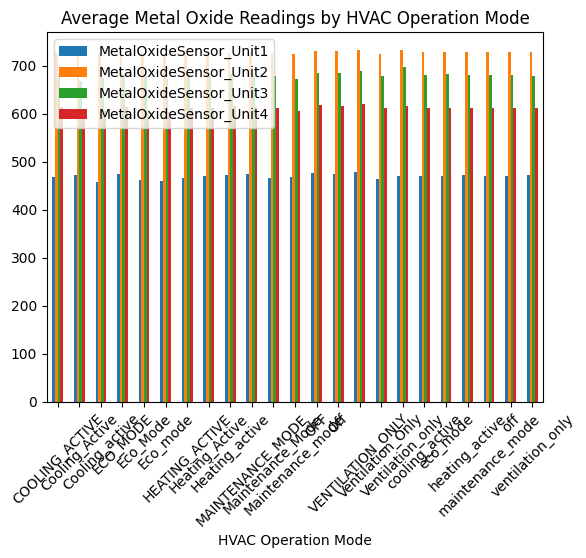

In [33]:
plt.figure(figsize=(12, 6))
df.groupby('HVAC Operation Mode')[mo_cols].mean().plot(kind='bar')
plt.title('Average Metal Oxide Readings by HVAC Operation Mode')
plt.legend(loc='best')
plt.xticks(rotation=45)
plt.show()

Insights:

Unit2 has around 14% missing values — above 5% threshold, impute with median.
Units 1, 3, 4 are complete (0 missing).
Units 1 & 3 show a wider spread with notable outliers visible in the box plot.
All four sensors operate on similar value ranges (~300–900), suggesting they measure comparable pollutants.

### 3.7 CO Gas Sensor

In [34]:
display(df['CO_GasSensor'].value_counts())
print(f"Missing: {df['CO_GasSensor'].isna().sum()} ({df['CO_GasSensor'].isna().sum()/len(df)*100:.1f}%)")

,count
CO_GasSensor,
1.0,4722
2.0,2748
0.0,1191
3.0,430
4.0,75


Missing: 834 (8.3%)


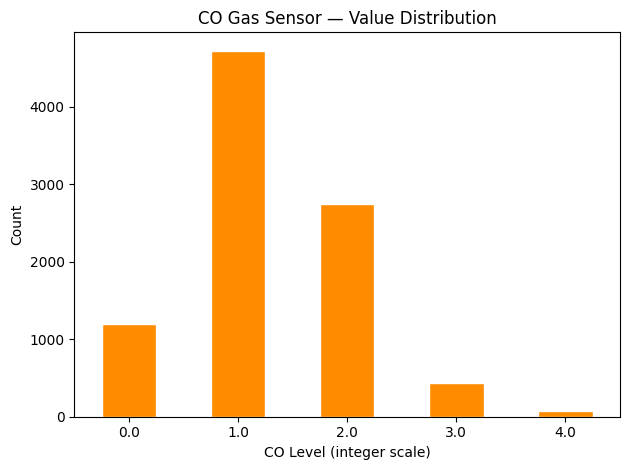

In [35]:
df['CO_GasSensor'].value_counts().sort_index().plot(kind='bar', color='darkorange', edgecolor='white')
plt.title('CO Gas Sensor — Value Distribution')
plt.xlabel('CO Level (integer scale)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Insights:

CO_GasSensor is a discrete ordinal variable (0–4), not continuous.
8.3% missing — above the 5% drop threshold; impute with mode (most frequent value = 1) since it is discrete.
The bar chart confirms value 1 is by far the most common reading.

### HVAC Operation Mode

In [36]:
display(df['HVAC Operation Mode'].value_counts())

,count
HVAC Operation Mode,
cooling_active,1502
maintenance_mode,1500
heating_active,1468
off,1456
eco_mode,1452
...,...
Maintenance_Mode,49
Maintenance_mode,48
Ventilation_Only,47


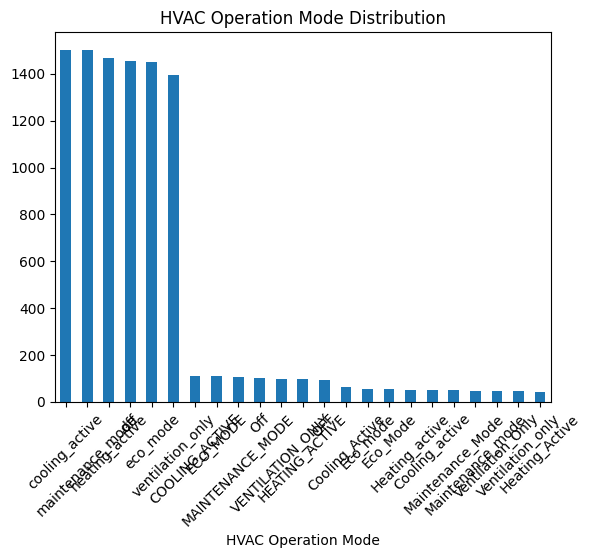

In [37]:
df['HVAC Operation Mode'].value_counts().plot(kind='bar')
plt.title('HVAC Operation Mode Distribution')
plt.xticks(rotation=45)
plt.show()

Insights:

No missing values, but 23 variant spellings exist for 6 logical categories (e.g., cooling_active, COOLING_ACTIVE, Cooling_Active, Cooling_active).
This is a label inconsistency / data entry issue — all variants mean the same category.
Action: Standardise all labels to lowercase underscore format (e.g., cooling_active).

### Ambient Light Level

In [38]:
display(df['Ambient Light Level'].value_counts())

,count
Ambient Light Level,
very_bright,3387
bright,2697
moderate,1463
dim,864
very_dim,535


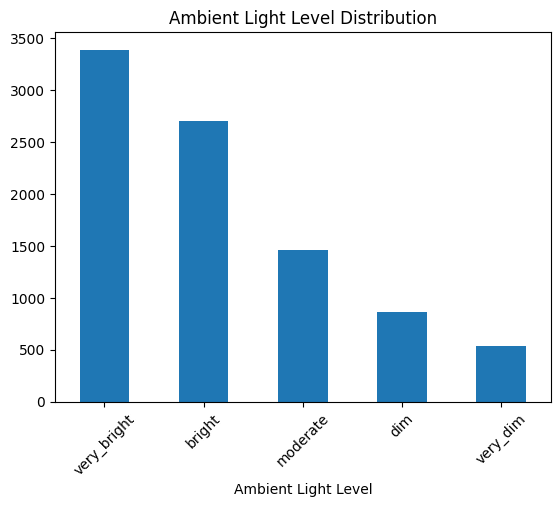

In [39]:
df['Ambient Light Level'].value_counts().plot(kind='bar')
plt.title('Ambient Light Level Distribution')
plt.xticks(rotation=45)
plt.show()

Insights:

10.5% missing — above the 5% drop threshold.
Labels are consistent (no casing issues) — only NaN needs handling.
Dominant category is very_bright (33.9%).
Action: Since this is a categorical ordinal column, drop rows with NaN (rather than imputing with mode) to avoid introducing bias into the ordinal structure.

### Activity Level

In [40]:
display(df['Activity Level'].value_counts())

,count
Activity Level,
Low Activity,5244
Moderate Activity,2812
High Activity,1095
ModerateActivity,326
Low_Activity,285
LowActivity,238


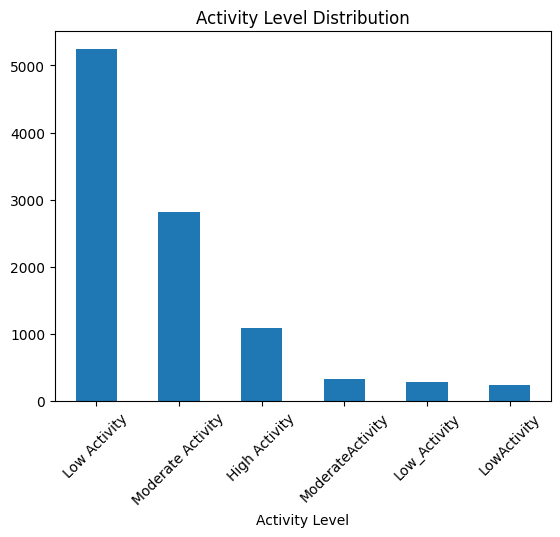

In [41]:
df['Activity Level'].value_counts().plot(kind='bar')
plt.title('Activity Level Distribution')
plt.xticks(rotation=45)
plt.show()

Insights:

No missing values, but 3 variant spellings exist: ModerateActivity (no space), Low_Activity (underscore), LowActivity (no separator).
Action: Standardise to canonical form: 'Low Activity', 'Moderate Activity', 'High Activity'.

# Column by Column Data Cleaning

### Temperature

In [42]:
# Replace unrealistic Temperature values (> 60°C) with NaN
df.loc[df['Temperature'] > 60, 'Temperature'] = np.nan
temp_median = df['Temperature'].median()
df['Temperature'] = df['Temperature'].fillna(temp_median)

In [43]:
display(df['Temperature'].describe())

,Temperature
count,10000.000000
mean,20.495026
std,2.740635
min,6.903485
25%,18.937500
50%,20.200000
75%,22.342500
max,34.301271


In [44]:
display(df['Temperature'].isna().sum())

np.int64(0)

### Humidity

In [45]:
# Replace negative Humidity values with NaN (physically impossible)
df.loc[df['Humidity'] < 0, 'Humidity'] = np.nan
humidity_median = df['Humidity'].median()
df['Humidity'] = df['Humidity'].fillna(humidity_median)

In [46]:
display(df['Humidity'].describe())

,Humidity
count,10000.000000
mean,53.174511
std,15.661224
min,39.690000
25%,49.190000
50%,51.570000
75%,53.200000
max,198.900000


In [47]:
display(df['Humidity'].isna().sum())

np.int64(0)

### CO2_InfraredSensor

In [48]:
#there is no error or missing values for C02 Infrared Sensor
display(df['CO2_InfraredSensor'].isna().sum())

np.int64(0)

### CO2_ElectroChemicalSensor

In [49]:
#there is no error or missing values for C02 ElectroChemical Sensor
display(df['CO2_InfraredSensor'].isna().sum())

np.int64(0)

### CO_GasSensor

In [50]:
co_median = df['CO_GasSensor'].median()
df['CO_GasSensor'] = df['CO_GasSensor'].fillna(co_median)
df['CO_GasSensor'] = df['CO_GasSensor'].astype(int)

In [51]:
display(df['CO_GasSensor'].isna().sum())

np.int64(0)

In [52]:
display(df['CO_GasSensor'].value_counts())

,count
CO_GasSensor,
1,5556
2,2748
0,1191
3,430
4,75


### Metal Oxide Sensors

In [53]:
mo_cols = [
    'MetalOxideSensor_Unit1',
    'MetalOxideSensor_Unit2',
    'MetalOxideSensor_Unit3',
    'MetalOxideSensor_Unit4'
]
display(df[mo_cols].isna().sum())

,0
MetalOxideSensor_Unit1,0
MetalOxideSensor_Unit2,1410
MetalOxideSensor_Unit3,0
MetalOxideSensor_Unit4,0


In [54]:
# Unit2 has ~14% missing values, impute with median
mo_median = df['MetalOxideSensor_Unit2'].median()
df['MetalOxideSensor_Unit2'] = df['MetalOxideSensor_Unit2'].fillna(mo_median)

In [55]:
display(df[mo_cols].isna().sum())

,0
MetalOxideSensor_Unit1,0
MetalOxideSensor_Unit2,0
MetalOxideSensor_Unit3,0
MetalOxideSensor_Unit4,0


### HVAC Operation Mode

In [56]:
display(df['HVAC Operation Mode'].isna().sum())

np.int64(0)

### Ambient Light Level

In [57]:
display(df['Ambient Light Level'].isna().sum())
display(df['Ambient Light Level'].value_counts())

np.int64(1054)

,count
Ambient Light Level,
very_bright,3387
bright,2697
moderate,1463
dim,864
very_dim,535


### Activity Level

In [58]:
display(df['Activity Level'].isna().sum())
display(df['Activity Level'].value_counts())

np.int64(0)

,count
Activity Level,
Low Activity,5244
Moderate Activity,2812
High Activity,1095
ModerateActivity,326
Low_Activity,285
LowActivity,238


## Cleaned info

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time of Day                10000 non-null  object 
 1   Temperature                10000 non-null  float64
 2   Humidity                   10000 non-null  float64
 3   CO2_InfraredSensor         10000 non-null  float64
 4   CO2_ElectroChemicalSensor  10000 non-null  float64
 5   MetalOxideSensor_Unit1     10000 non-null  float64
 6   MetalOxideSensor_Unit2     10000 non-null  float64
 7   MetalOxideSensor_Unit3     10000 non-null  float64
 8   MetalOxideSensor_Unit4     10000 non-null  float64
 9   CO_GasSensor               10000 non-null  int64  
 10  Session ID                 10000 non-null  int64  
 11  HVAC Operation Mode        10000 non-null  object 
 12  Ambient Light Level        8946 non-null   object 
 13  Activity Level             10000 non-null  obje

## Export clean database

In [60]:
from google.colab import files

In [61]:
clean_conn = sqlite3.connect('gas_monitoring_cleaned.db')
df.to_sql('gas_monitoring', clean_conn, if_exists='replace', index=False)
clean_conn.close()

files.download('gas_monitoring_cleaned.db')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>